In [41]:
%matplotlib widget

β = 1.0437  |  intercept = 0.5396  |  train: 1258 steps, test: 3774 steps


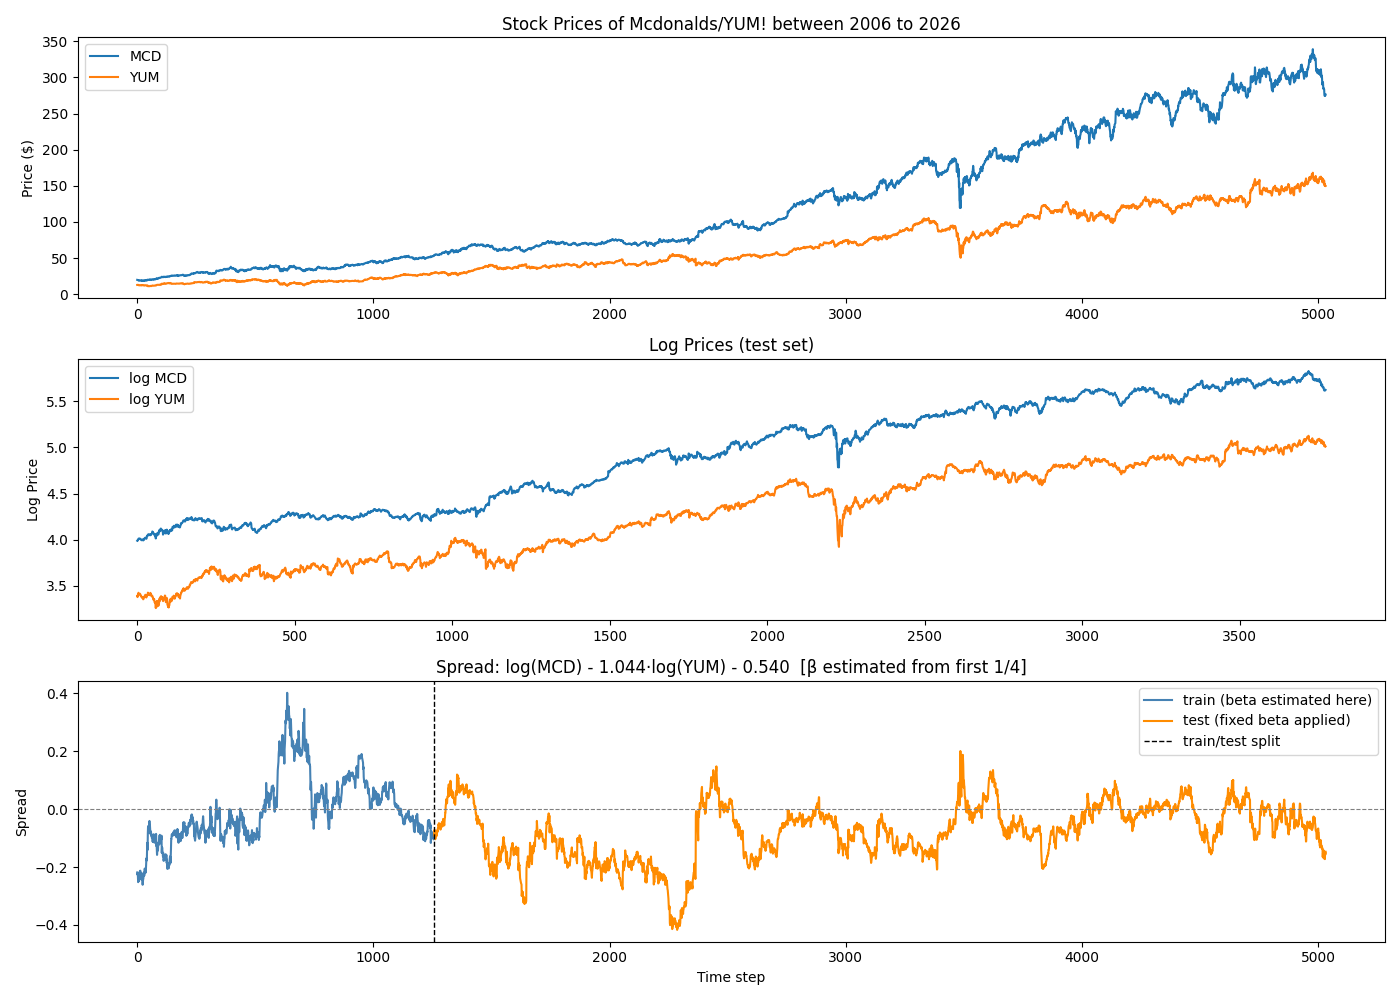

In [42]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from data_loader import PairData

data = PairData("../../data/real_pair_MCD_YUM.csv")
s0, s1 = data.s[0], data.s[1]
labels = data.labels
n = len(s0)
train_end = n // 4

# Estimate beta on first 1/4 only
log_s0, log_s1 = np.log(s0), np.log(s1)
jres = coint_johansen(np.column_stack([log_s0[:train_end], log_s1[:train_end]]), det_order=0, k_ar_diff=1)
cv   = jres.evec[:, 0]
beta = -cv[1] / cv[0]

# Intercept from training period so spread is centred around 0
intercept = (log_s0[:train_end] - beta * log_s1[:train_end]).mean()

spread_train = log_s0[:train_end] - beta * log_s1[:train_end] - intercept
spread_test  = log_s0[train_end:] - beta * log_s1[train_end:] - intercept

print(f"β = {beta:.4f}  |  intercept = {intercept:.4f}  |  train: {train_end} steps, test: {n - train_end} steps")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# --- Prices (test set only) ---
axes[0].plot(s0, label=labels[0])
axes[0].plot(s1, label=labels[1])
axes[0].set_title("Stock Prices of Mcdonalds/YUM! between 2006 to 2026")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

# --- Log prices (test set only) ---
axes[1].plot(log_s0[train_end:], label=f"log {labels[0]}")
axes[1].plot(log_s1[train_end:], label=f"log {labels[1]}")
axes[1].set_title("Log Prices (test set)")
axes[1].set_ylabel("Log Price")
axes[1].legend()

# --- Spread: train + test, separated by vertical line ---
ax = axes[2]
ax.plot(np.arange(train_end),         spread_train, color="steelblue",  label="train (beta estimated here)")
ax.plot(np.arange(train_end, n),      spread_test,  color="darkorange", label="test (fixed beta applied)")
ax.axvline(train_end, color="black", linewidth=1, linestyle="--", label="train/test split")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title(f"Spread: log(MCD) - {beta:.3f}·log(YUM) - {intercept:.3f}  [β estimated from first 1/4]")
ax.set_ylabel("Spread")
ax.set_xlabel("Time step")
ax.legend()

plt.tight_layout()
plt.show()


β (Q3) = 1.1640  |  intercept = -0.0504  |  Q3: 1258 steps, Q4: 1258 steps


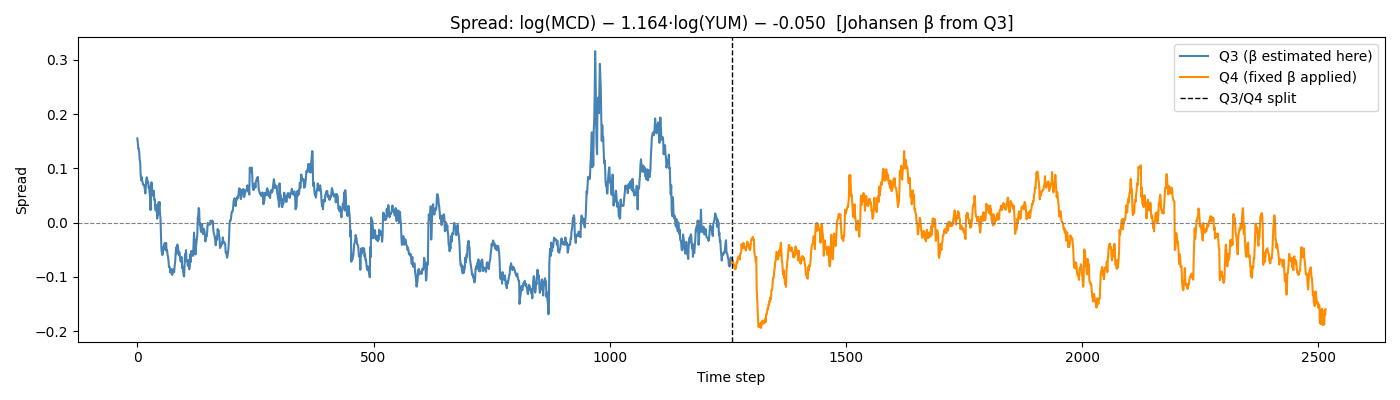

In [43]:
# Q3/Q4 spread: beta estimated on Q3, applied to Q4
q3_start = n // 2
q3_end   = 3 * n // 4

log_s0_q3 = log_s0[q3_start:q3_end]
log_s1_q3 = log_s1[q3_start:q3_end]

jres_q3      = coint_johansen(np.column_stack([log_s0_q3, log_s1_q3]), det_order=0, k_ar_diff=1)
cv_q3        = jres_q3.evec[:, 0]
beta_q3      = -cv_q3[1] / cv_q3[0]
intercept_q3 = (log_s0_q3 - beta_q3 * log_s1_q3).mean()

q3_len = q3_end - q3_start
q4_len = n - q3_end

spread_q3 = log_s0[q3_start:q3_end] - beta_q3 * log_s1[q3_start:q3_end] - intercept_q3
spread_q4 = log_s0[q3_end:]         - beta_q3 * log_s1[q3_end:]         - intercept_q3

print(f"β (Q3) = {beta_q3:.4f}  |  intercept = {intercept_q3:.4f}  |  Q3: {q3_len} steps, Q4: {q4_len} steps")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.arange(q3_len),                  spread_q3, color="steelblue",  label="Q3 (β estimated here)")
ax.plot(np.arange(q3_len, q3_len + q4_len), spread_q4, color="darkorange", label="Q4 (fixed β applied)")
ax.axvline(q3_len, color="black", linewidth=1, linestyle="--", label="Q3/Q4 split")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title(f"Spread: log(MCD) − {beta_q3:.3f}·log(YUM) − {intercept_q3:.3f}  [Johansen β from Q3]")
ax.set_ylabel("Spread")
ax.set_xlabel("Time step")
ax.legend()
plt.tight_layout()
plt.show()

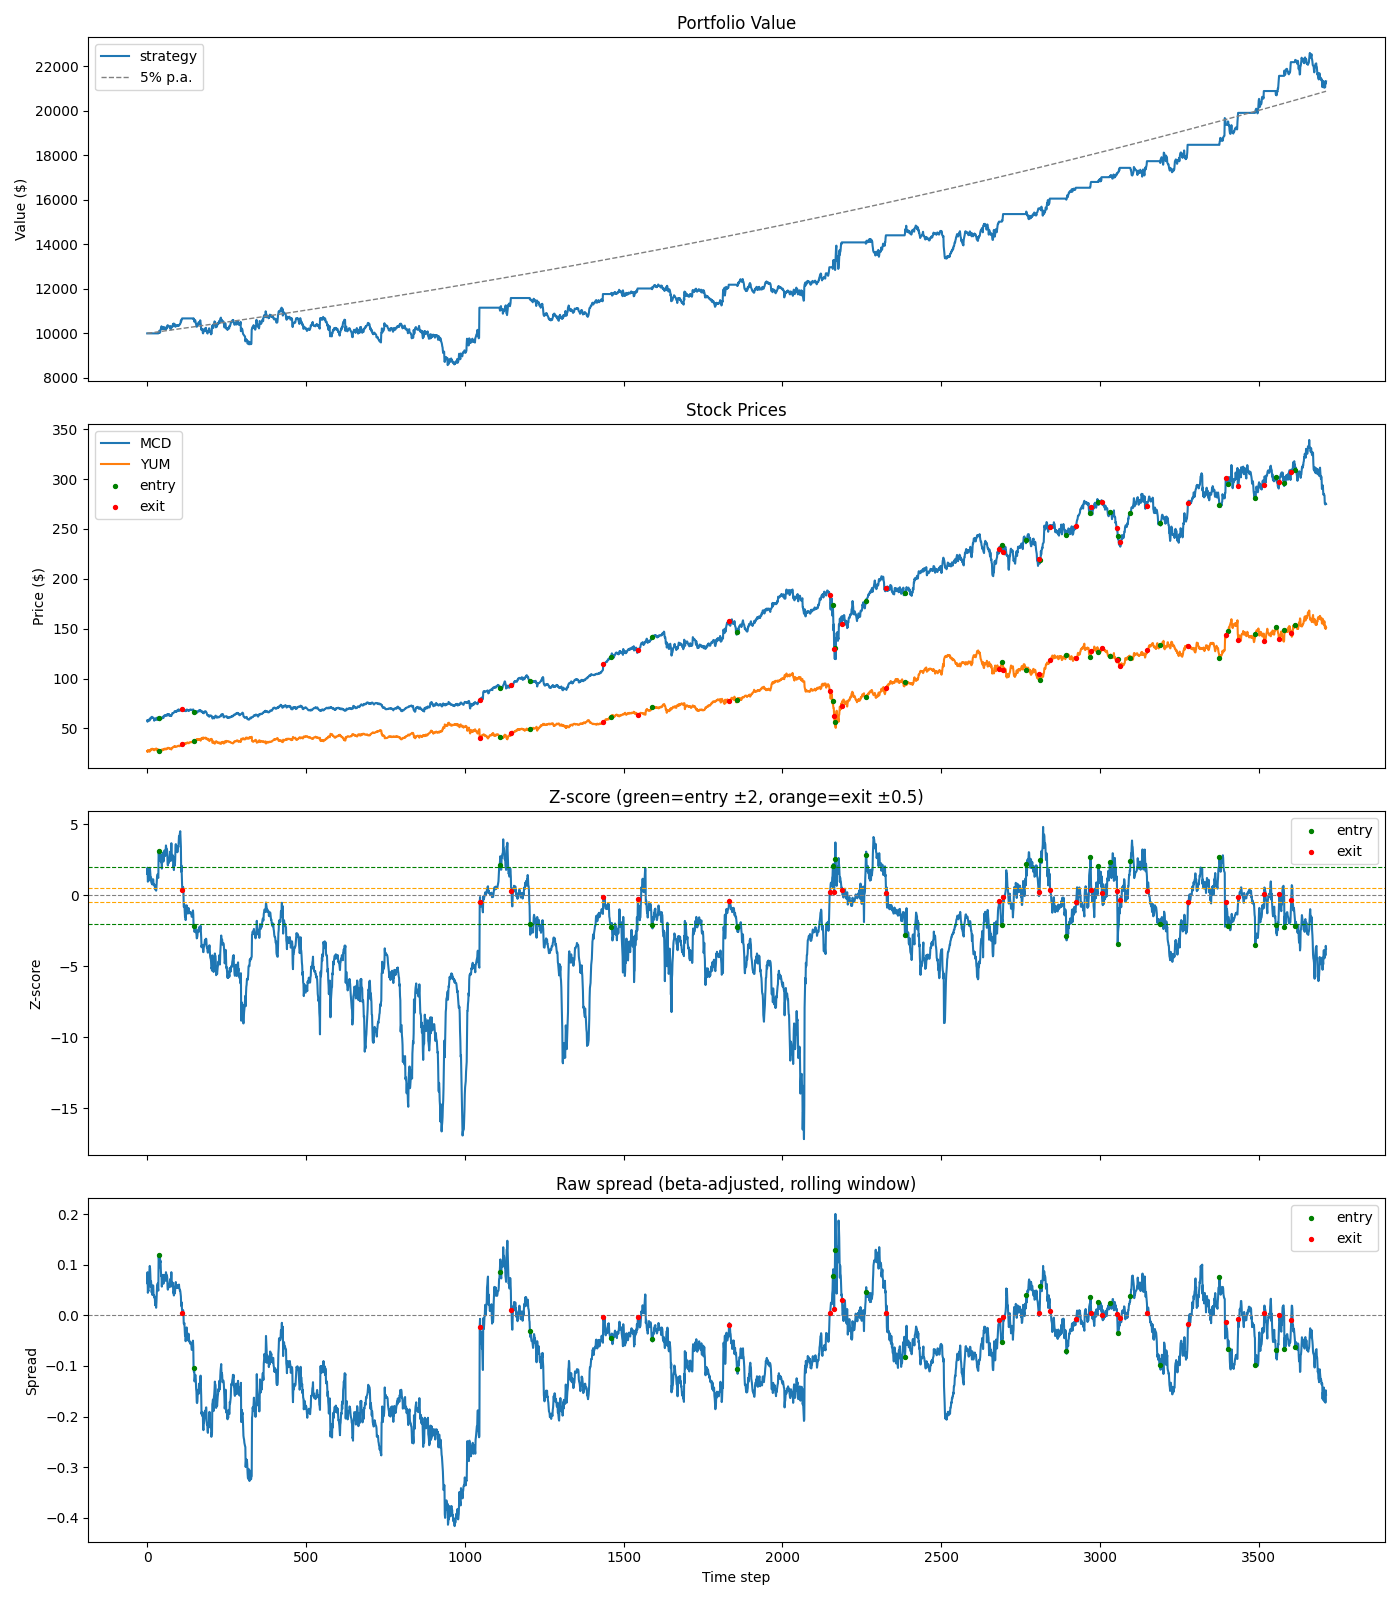

In [44]:
from env import Market
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

test_data = data.slice(train_end)
env = Market(test_data, fixed_beta=beta, spread_intercept=intercept)
results = run_strategy(env, ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
plot_strategy(results)


In [45]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import pandas as pd

def mean_reversion_report(series, label):
    s = np.asarray(series)

    # ADF: H0 = unit root (non-stationary)
    adf_stat, adf_p, _, _, adf_cv, _ = adfuller(s, autolag="AIC")

    # KPSS: H0 = stationary
    kpss_stat, kpss_p, _, kpss_cv = kpss(s, regression="c", nlags="auto")

    # Half-life via OLS: Δy = α + β·y_{t-1}  →  half-life = -ln(2)/β
    delta_s = np.diff(s)
    lag_s   = s[:-1]
    res     = OLS(delta_s, add_constant(lag_s)).fit()
    beta_hl = res.params[1]
    half_life = -np.log(2) / beta_hl if beta_hl < 0 else np.inf

    print(f"\n{'='*52}")
    print(f"  {label}")
    print(f"{'='*52}")
    print(f"  ADF  stat={adf_stat:+.4f}  p={adf_p:.4f}  "
          f"(1%={adf_cv['1%']:.3f}, 5%={adf_cv['5%']:.3f})")
    print(f"  KPSS stat={kpss_stat:+.4f}  p={kpss_p:.4f}  "
          f"(1%={kpss_cv['1%']:.3f}, 5%={kpss_cv['5%']:.3f})")
    print(f"  Half-life of mean reversion: {half_life:.1f} days")

    adf_ok  = adf_p  < 0.05
    kpss_ok = kpss_p > 0.05
    print(f"\n  ADF  rejects unit root  (stationary): {'YES' if adf_ok  else 'NO'}")
    print(f"  KPSS fails to reject   (stationary): {'YES' if kpss_ok else 'NO'}")
    conclusion = "STATIONARY & mean-reverting" if (adf_ok and kpss_ok) else \
                 "MIXED evidence"              if (adf_ok or kpss_ok)  else \
                 "NOT stationary"
    print(f"  --> {conclusion}")

mean_reversion_report(spread_q3, "Q3 spread (in-sample, β estimated here)")
mean_reversion_report(spread_q4, "Q4 spread (out-of-sample, fixed β)")


  Q3 spread (in-sample, β estimated here)
  ADF  stat=-2.9676  p=0.0380  (1%=-3.436, 5%=-2.864)
  KPSS stat=+0.3639  p=0.0927  (1%=0.739, 5%=0.463)
  Half-life of mean reversion: 37.6 days

  ADF  rejects unit root  (stationary): YES
  KPSS fails to reject   (stationary): YES
  --> STATIONARY & mean-reverting

  Q4 spread (out-of-sample, fixed β)
  ADF  stat=-3.0366  p=0.0316  (1%=-3.436, 5%=-2.864)
  KPSS stat=+0.6621  p=0.0170  (1%=0.739, 5%=0.463)
  Half-life of mean reversion: 43.1 days

  ADF  rejects unit root  (stationary): YES
  KPSS fails to reject   (stationary): NO
  --> MIXED evidence


Hedge ratio (full dataset): β = 1.0391,  intercept = 0.4990


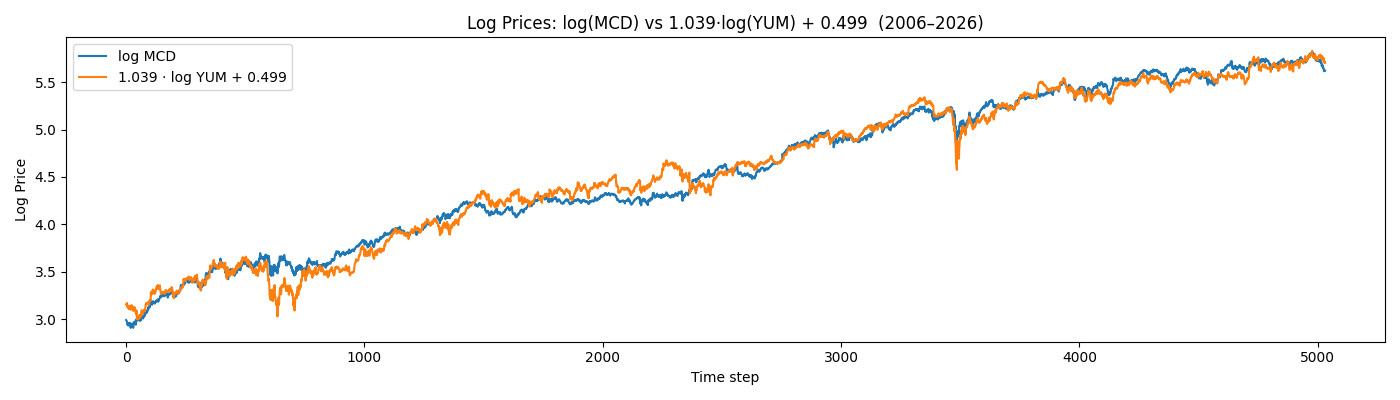

In [46]:
# Hedge ratio from full dataset
jres_full      = coint_johansen(np.column_stack([log_s0, log_s1]), det_order=0, k_ar_diff=1)
cv_full        = jres_full.evec[:, 0]
beta_full      = -cv_full[1] / cv_full[0]
intercept_full = (log_s0 - beta_full * log_s1).mean()

print(f"Hedge ratio (full dataset): β = {beta_full:.4f},  intercept = {intercept_full:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(log_s0,                                label=f"log {labels[0]}")
ax.plot(beta_full * log_s1 + intercept_full,   label=f"{beta_full:.3f} · log {labels[1]} + {intercept_full:.3f}")
ax.set_title(f"Log Prices: log(MCD) vs {beta_full:.3f}·log(YUM) + {intercept_full:.3f}  (2006–2026)")
ax.set_ylabel("Log Price")
ax.set_xlabel("Time step")
ax.legend()
plt.tight_layout()
plt.show()

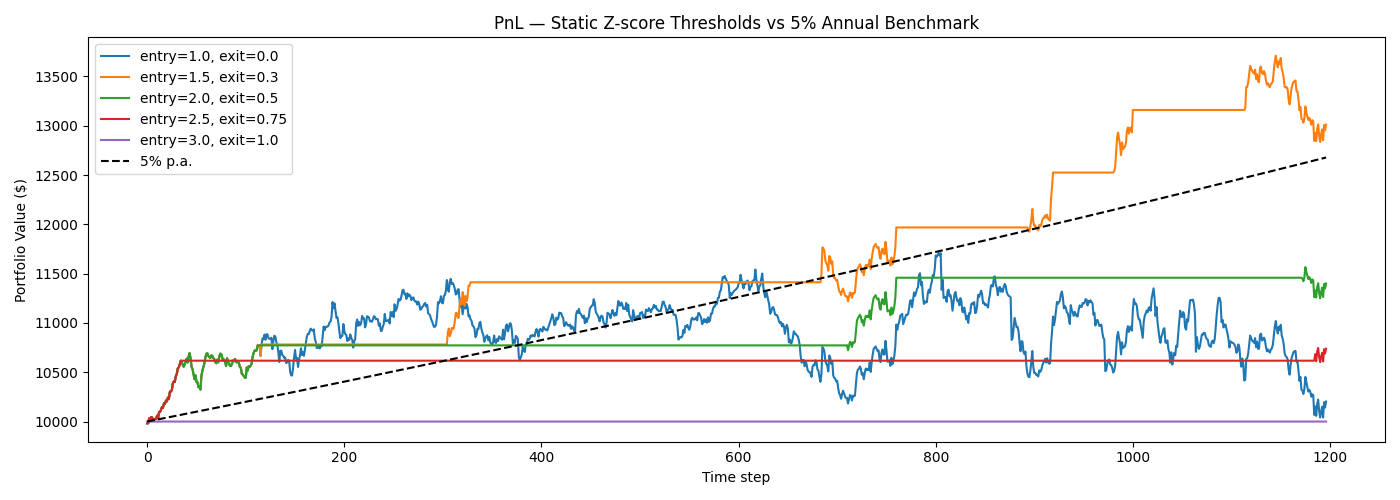

In [47]:
from env import Market
from static_thresh_base import ZScoreBaseline
from runner import run_strategy

# Q3 stats → used to fix the env for Q4
spread_std_q3 = spread_q3.std()

q4_data = data.slice(q3_end)
thresholds = [
    (1.0, 0.0),
    (1.5, 0.3),
    (2.0, 0.5),
    (2.5, 0.75),
    (3.0, 1.0),
]

fig, ax = plt.subplots(figsize=(14, 5))

for entry, exit_ in thresholds:
    env = Market(q4_data, fixed_beta=beta_q3, spread_intercept=intercept_q3, fixed_std=spread_std_q3)
    results = run_strategy(env, ZScoreBaseline(entry_threshold=entry, exit_threshold=exit_))
    pnl = results["pnl"]
    ax.plot(pnl, label=f"entry={entry}, exit={exit_}")

# 5% annual compound benchmark
n_steps = len(pnl)
benchmark = 10000 * (1 + 0.05 / 252) ** np.arange(n_steps)
ax.plot(benchmark, color="black", linewidth=1.5, linestyle="--", label="5% p.a.")

ax.set_title("PnL — Static Z-score Thresholds vs 5% Annual Benchmark")
ax.set_ylabel("Portfolio Value ($)")
ax.set_xlabel("Time step")
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd

rf_daily = 0.05 / 252

rows = []
for entry, exit_ in thresholds:
    env = Market(q4_data, fixed_beta=beta_q3, spread_intercept=intercept_q3, fixed_std=spread_std_q3)
    res = run_strategy(env, ZScoreBaseline(entry_threshold=entry, exit_threshold=exit_))
    pnl = res["pnl"]
    daily_returns  = np.diff(pnl) / pnl[:-1]
    excess_returns = daily_returns - rf_daily
    sharpe = (excess_returns.mean() / (excess_returns.std() + 1e-12)) * np.sqrt(252)
    rows.append({"Entry threshold": entry, "Exit threshold": exit_, "Sharpe ratio": round(sharpe, 3)})

df = pd.DataFrame(rows)
display(df)

,Entry threshold,Exit threshold,Sharpe ratio
0,1.0,0.00,-4.580000e-01
1,1.5,0.30,1.520000e-01
2,2.0,0.50,-7.450000e-01
3,2.5,0.75,-2.483000e+00
4,3.0,1.00,-3.149704e+09


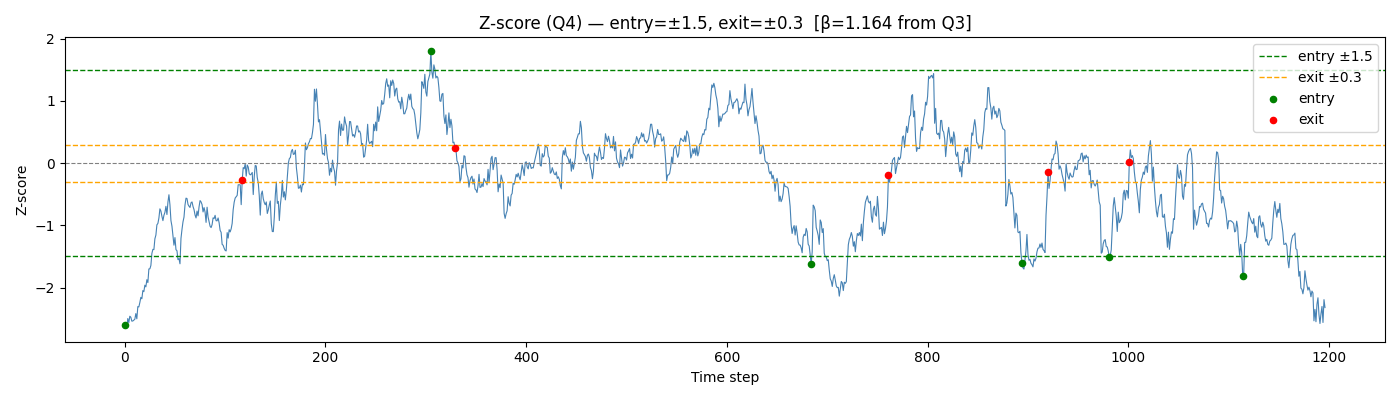

In [49]:
env_best = Market(q4_data, fixed_beta=beta_q3, spread_intercept=intercept_q3, fixed_std=spread_std_q3)
results_best = run_strategy(env_best, ZScoreBaseline(entry_threshold=1.5, exit_threshold=0.3))

zscores = results_best["zscores"]
entries = results_best["entries"]
exits   = results_best["exits"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(zscores, color="steelblue", linewidth=0.8)
ax.axhline( 0,   color="gray",   linewidth=0.8, linestyle="--")
ax.axhline( 1.5, color="green",  linewidth=1.0, linestyle="--", label="entry ±1.5")
ax.axhline(-1.5, color="green",  linewidth=1.0, linestyle="--")
ax.axhline( 0.3, color="orange", linewidth=1.0, linestyle="--", label="exit ±0.3")
ax.axhline(-0.3, color="orange", linewidth=1.0, linestyle="--")
if entries:
    ax.scatter(entries, zscores[entries], color="green", zorder=5, s=20, label="entry")
if exits:
    ax.scatter(exits,   zscores[exits],   color="red",   zorder=5, s=20, label="exit")
ax.set_title(f"Z-score (Q4) — entry=±1.5, exit=±0.3  [β={beta_q3:.3f} from Q3]")
ax.set_ylabel("Z-score")
ax.set_xlabel("Time step")
ax.legend()
plt.tight_layout()
plt.show()

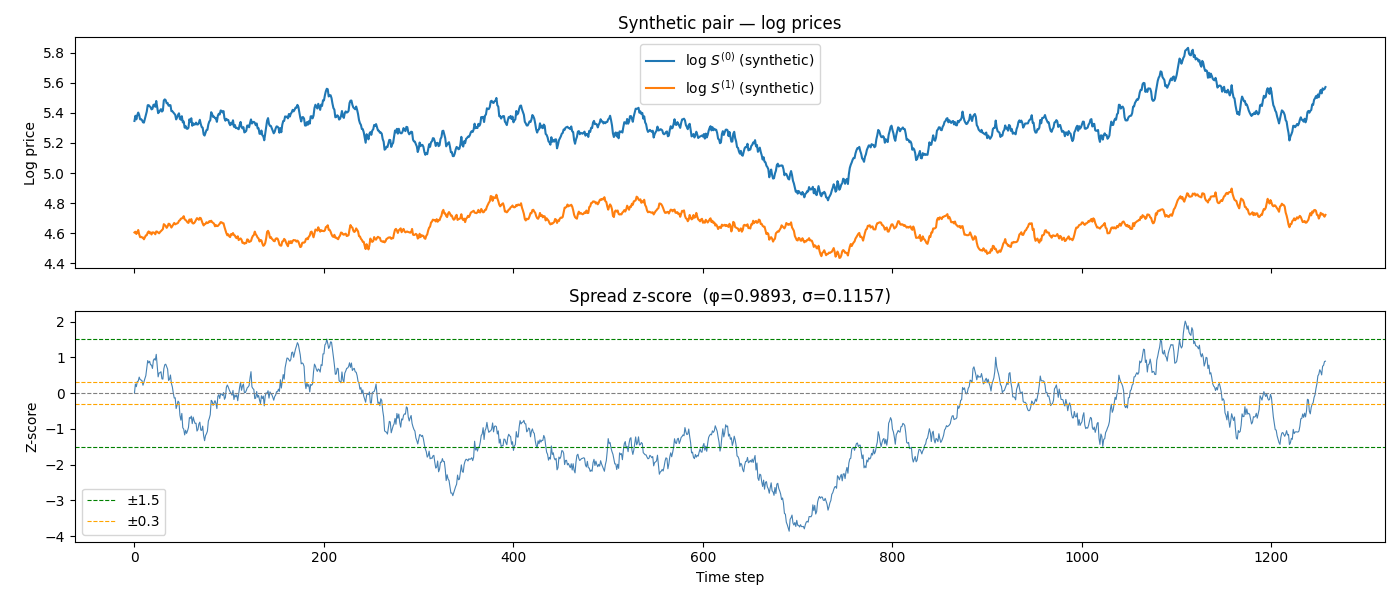

In [50]:
from statsmodels.tsa.ar_model import AutoReg

# Calibrate from Q1
phi_syn    = AutoReg(spread_train, lags=1).fit().params[1]
std_syn    = float(spread_train.std())
wn_var_syn = std_syn ** 2 * (1 - phi_syn ** 2)
T_syn      = train_end  # same length as Q1

# Generate one synthetic pair
rng         = np.random.default_rng(42)
log_s1_syn  = np.cumsum(np.concatenate([[np.log(100.0)],
                         0.0005 + 0.015 * rng.standard_normal(T_syn - 1)]))
noise_syn   = np.sqrt(wn_var_syn) * rng.standard_normal(T_syn)
spread_syn  = np.zeros(T_syn)
for t in range(1, T_syn):
    spread_syn[t] = phi_syn * spread_syn[t - 1] + noise_syn[t]

log_s0_syn  = beta * log_s1_syn + intercept + spread_syn
zscore_syn  = spread_syn / (std_syn + 1e-8)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(log_s0_syn, label="log $S^{(0)}$ (synthetic)")
axes[0].plot(log_s1_syn, label="log $S^{(1)}$ (synthetic)")
axes[0].set_title("Synthetic pair — log prices")
axes[0].set_ylabel("Log price")
axes[0].legend()

axes[1].plot(zscore_syn, color="steelblue", linewidth=0.8)
axes[1].axhline( 0,   color="gray",   linewidth=0.8, linestyle="--")
axes[1].axhline( 1.5, color="green",  linewidth=0.8, linestyle="--", label="±1.5")
axes[1].axhline(-1.5, color="green",  linewidth=0.8, linestyle="--")
axes[1].axhline( 0.3, color="orange", linewidth=0.8, linestyle="--", label="±0.3")
axes[1].axhline(-0.3, color="orange", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Spread z-score  (φ={phi_syn:.4f}, σ={std_syn:.4f})")
axes[1].set_ylabel("Z-score")
axes[1].set_xlabel("Time step")
axes[1].legend()

plt.tight_layout()
plt.show()